# HMM Gaussian Alpha -- Generation de signaux directionnels par modeles de Markov caches

**Serie** : Probabilites appliquees au trading
**Duree estimee** : 90 minutes
**Niveau** : Avance (graduate-level AI/ML)
**Prerequis** : Python 3.10+, notions de chaines de Markov, probabilites, trading

**Reference** : Broad, J. (2025). *Hands-On AI Trading with Python*, Chapitre 6, Exercice 4.

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. Modeliser les regimes de marche avec des chaines de Markov cachees (HMM gaussiens)
2. Distinguer l'usage d'un HMM comme **source alpha** (signal directionnel) vs detecteur de regime
3. Implment un HMM a 2 etats (baseline Broad Ex4) puis 3 etats sur des donnees crypto
4. Valider la robustesse par walk-forward 5-fold x 4 seeds avec couts de transaction
5. Produire un verdict explicite (BEATS / NO BEATS / INCONCLUSIVE) contre le benchmark buy-and-hold

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [Catalogue Probas](README.md) | -- |

---

## Introduction

Les **modeles de Markov caches (HMM)** sont des modeles probabilistes ou le systeme evolue entre etats non observes ("caches"), et les observations (rendements, volatilite) sont des emissions probabilistes depuis ces etats.

En finance, les etats caches correspondent typiquement a des **regimes de marche** : tendance haussiere, tendance baissiere, range/consolidation. L'idee fondamentale est que les transitions entre regimes suivent une chaine de Markov -- l'etat futur depend seulement de l'etat present.

### HMM comme source alpha vs detecteur de regime

L'approche la plus courante consiste a utiliser l'HMM comme detecteur de regime pour piloter un melange d'experts (MoE). Ce notebook adopte une approche differente, inspiree de **Broad Ch6 Ex4** :

- **Source alpha** : les predictions d'etat de l'HMM generent directement des signaux long/short/flat
- L'etat avec la moyenne de rendement la plus elevee -> signal LONG
- L'etat avec la moyenne negative -> signal FLAT ou SHORT
- Pas de MoE, pas de modele secondaire -- l'HMM est le generateur de signal

### Plan du notebook

1. Chargement et preparation des donnees (BTC + ETH)
2. Feature engineering pour l'HMM
3. HMM gaussien 2-etats (baseline Broad Ex4)
4. Generation de signaux et backtest in-sample
5. Extension a 3 etats avec selection par AIC/BIC
6. Validation walk-forward 5-fold x 4 seeds
7. Verdict explicite et extension multi-actif

## 1. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("Imports OK")
print(f"numpy {np.__version__}")
print(f"pandas {pd.__version__}")

Imports OK
numpy 2.4.2
pandas 3.0.2


## 2. Chargement et preparation des donnees

Nous utilisons les donnees BTC-USD journalieres depuis le CSV Bitstamp (source principale) avec un fallback yfinance. Les donnees ETH-USD sont chargees via yfinance. Les deux series sont fusionnees sur l'index temporel pour les analyses multi-actif.

In [2]:
# Data loading with fallback
btc_csv_path = "G:/Mon Drive/MyIA/Dev/Trading/Data/Bitstamp_BTCUSD_1h_2014-20240808.csv"

try:
    btc = pd.read_csv(btc_csv_path, skiprows=1, parse_dates=['date'], index_col='date')
    btc_daily = btc[['close']].resample('D').last().dropna()
    btc_daily.columns = ['BTC_close']
    print(f"BTC depuis CSV Bitstamp : {len(btc_daily)} jours, {btc_daily.index[0].date()} -> {btc_daily.index[-1].date()}")
except FileNotFoundError:
    import yfinance as yf
    btc = yf.download('BTC-USD', start='2014-01-01', end='2024-08-09')
    btc_daily = btc[['Close']].copy()
    btc_daily.columns = ['BTC_close']
    print(f"BTC depuis yfinance (fallback) : {len(btc_daily)} jours")

BTC depuis CSV Bitstamp : 2279 jours, 2018-05-15 -> 2024-08-09


### Chargement ETH et fusion du panel

Maintenant que les donnees BTC sont chargees, nous ajoutons l'ETH-USD et fusionnons les deux series sur l'index temporel commun.

In [3]:
# Load ETH-USD via yfinance
import yfinance as yf

eth = yf.download('ETH-USD', start='2017-01-01', end='2024-08-09')
eth_daily = eth[['Close']].copy()
eth_daily.columns = ['ETH_close']
print(f"ETH charge : {len(eth_daily)} jours, {eth_daily.index[0].date()} -> {eth_daily.index[-1].date()}")

# Merge on date index (inner join to keep only overlapping dates)
prices = btc_daily.join(eth_daily, how='inner').dropna()
print(f"\nPanel fusionne : {len(prices)} jours")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

ETH charge : 2465 jours, 2017-11-09 -> 2024-08-08

Panel fusionne : 2278 jours
            BTC_close    ETH_close
date                              
2024-08-04    58142.0  2686.398926
2024-08-05    54014.0  2417.206299
2024-08-06    56053.0  2458.723877
2024-08-07    55136.0  2336.589355
2024-08-08    61699.0  2683.352783


### Chargement SOL-USD et extension du panel

Pour l'analyse multi-actif complete, nous ajoutons le SOL-USD (3e crypto-actif par capitalisation). Le panel resultant couvre BTC + ETH + SOL, permettant des features cross-asset et un HMM joint.

In [4]:
# Load SOL-USD via yfinance
sol = yf.download('SOL-USD', start='2020-01-01', end='2024-08-09')
sol_daily = sol[['Close']].copy()
sol_daily.columns = ['SOL_close']
print(f"SOL charge : {len(sol_daily)} jours, {sol_daily.index[0].date()} -> {sol_daily.index[-1].date()}")

# Merge into panel
prices = prices.join(sol_daily, how='inner').dropna()
print(f"\nPanel fusionne 3-actifs : {len(prices)} jours, {prices.columns.tolist()}")
print(prices.tail())

[*********************100%***********************]  1 of 1 completed

SOL charge : 1582 jours, 2020-04-10 -> 2024-08-08

Panel fusionne 3-actifs : 1582 jours, ['BTC_close', 'ETH_close', 'SOL_close']
            BTC_close    ETH_close   SOL_close
date                                          
2024-08-04    58142.0  2686.398926  138.055084
2024-08-05    54014.0  2417.206299  129.864304
2024-08-06    56053.0  2458.723877  144.090363
2024-08-07    55136.0  2336.589355  144.632095
2024-08-08    61699.0  2683.352783  162.930740


## 3. Feature engineering

### Construction des variables pour le HMM

Le HMM gaussien utilise les observations pour inferer les etats caches. Nous construisons un jeu de features pertinent pour capturer les regimes de marche :

| Feature | Formule | Rationale |
|---------|---------|------------|
| Log-rendement | $r_t = \ln(P_t / P_{t-1})$ | Signal directionnel brut |
| Volatilite realisee 20j | $\sigma_{20} = \sqrt{\sum_{i=0}^{19} r_{t-i}^2}$ | Regime de volatilite |
| Momentum 5j | $m_5 = \sum_{i=0}^{4} r_{t-i}$ | Tendance court terme |

La **normalisation** des features est essentielle pour la convergence de l'algorithme EM du HMM gaussien (Broad Ch6 recommande le StandardScaler).

### Visualisation des features

Observons la distribution temporelle des features avant de les injecter dans le HMM.

In [5]:
# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Feature engineering -- BTC base features + cross-asset
features = pd.DataFrame(index=returns.index)
features['btc_ret'] = returns['BTC_close']
features['btc_vol20'] = returns['BTC_close'].rolling(20).std()
features['btc_mom5'] = returns['BTC_close'].rolling(5).sum()

# Cross-asset features
if 'ETH_close' in returns.columns:
    features['eth_ret'] = returns['ETH_close']
    features['btc_eth_corr'] = returns['BTC_close'].rolling(20).corr(returns['ETH_close'])
if 'SOL_close' in returns.columns:
    features['sol_ret'] = returns['SOL_close']
    features['btc_sol_corr'] = returns['BTC_close'].rolling(20).corr(returns['SOL_close'])

# Relative momentum (cross-asset)
if 'ETH_close' in returns.columns and 'SOL_close' in returns.columns:
    features['rel_mom_btc_eth'] = returns['BTC_close'].rolling(10).sum() - returns['ETH_close'].rolling(10).sum()
    features['rel_mom_btc_sol'] = returns['BTC_close'].rolling(10).sum() - returns['SOL_close'].rolling(10).sum()

# Drop NaN from rolling windows
features = features.dropna()

print(f"Features : {features.shape[0]} observations, {features.shape[1]} colonnes")
print(f"Colonnes : {list(features.columns)}")
print(features.describe().round(5))

Features : 1562 observations, 9 colonnes
Colonnes : ['btc_ret', 'btc_vol20', 'btc_mom5', 'eth_ret', 'btc_eth_corr', 'sol_ret', 'btc_sol_corr', 'rel_mom_btc_eth', 'rel_mom_btc_sol']
          btc_ret   btc_vol20    btc_mom5     eth_ret  btc_eth_corr  \
count  1562.00000  1562.00000  1562.00000  1562.00000    1562.00000   
mean      0.00125     0.03046     0.00632     0.00161       0.82129   
std       0.03277     0.01169     0.07289     0.04211       0.11991   
min      -0.16904     0.00602    -0.33137    -0.31746       0.22937   
25%      -0.01306     0.02168    -0.02974    -0.01700       0.75877   
50%       0.00042     0.02973     0.00501     0.00140       0.84376   
75%       0.01644     0.03711     0.04494     0.02223       0.91832   
max       0.17773     0.06958     0.22892     0.23070       0.98222   

          sol_ret  btc_sol_corr  rel_mom_btc_eth  rel_mom_btc_sol  
count  1562.00000    1562.00000       1562.00000       1562.00000  
mean      0.00345       0.58865         -0.

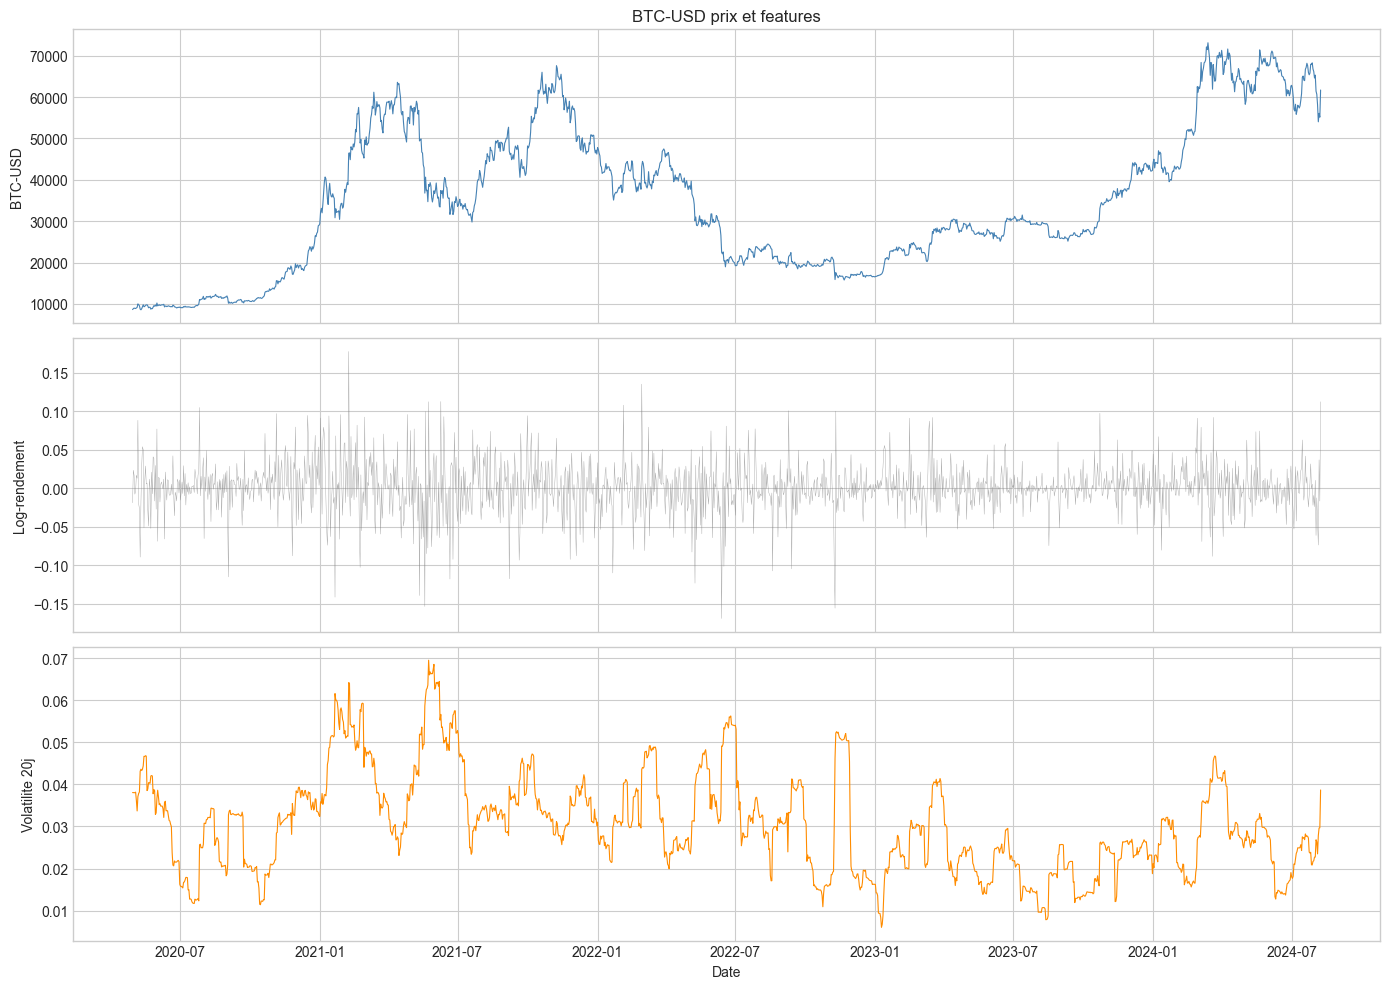

In [6]:
# Visualize BTC price and returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

btc_aligned = prices['BTC_close'].reindex(features.index)

axes[0].plot(btc_aligned.index, btc_aligned.values, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('BTC-USD')
axes[0].set_title('BTC-USD prix et features')

axes[1].plot(features.index, features['btc_ret'].values, color='gray', linewidth=0.3, alpha=0.7)
axes[1].set_ylabel('Log-rendement')

axes[2].plot(features.index, features['btc_vol20'].values, color='darkorange', linewidth=0.8)
axes[2].set_ylabel('Volatilite 20j')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Interpretation : Distribution des features

Les log-rendements BTC montrent la caracteristique "fat tails" typique des crypto-actifs : une distribution centree sur zero mais avec des outliers frequents (crashes et rallies). La volatilite 20j oscille entre periodes calmes et pic de stress, ce qui est precisement ce que le HMM doit capturer comme regimes distincts.

### Entrainement et decodage des etats

Nous normalisons les features et fittons le HMM. L'algorithme EM (Baum-Welch) estibe les parametres, puis Viterbi decode la sequence d'etats la plus probable.

## 4. HMM gaussien a 2 etats -- Baseline Broad Ex4

Conformement a l'exercice 4 du chapitre 6 de Broad, nous commencons par un **HMM gaussien a 2 etats**. Le choix de 2 etats est la configuration minimale : un etat "bull" (rendement positif, faible volatilite) et un etat "bear" (rendement negatif, forte volatilite).

### Modele

Un HMM gaussien est defini par le triplet $\lambda = (A, B, \pi)$ :

- **A** : matrice de transition $a_{ij} = P(s_{t+1} = j | s_t = i)$
- **B** : distributions d'emission $b_i(x) = \mathcal{N}(x | \mu_i, \Sigma_i)$
- $\pi$ : distribution initiale des etats

L'apprentissage se fait par l'algorithme **EM (Baum-Welch)**, et l'inference des etats caches par **Viterbi** (chemin le plus probable).

In [7]:
# Normalize features for HMM convergence (Broad Ch6 recommendation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[['btc_ret', 'btc_vol20', 'btc_mom5']])

# Fit 2-state Gaussian HMM
model_2s = hmm.GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_2s.fit(X_scaled)

# Decode states via Viterbi
states_2s = model_2s.predict(X_scaled)

print("=== HMM Gaussien 2 etats ===")
print(f"\nMatrice de transition A :")
print(np.round(model_2s.transmat_, 4))
print(f"\nMoyennes (espace standardise) :")
print(np.round(model_2s.means_, 4))
print(f"\nCovariances :")
for i, cov in enumerate(model_2s.covars_):
    print(f"  Etat {i}: diag = {np.round(np.diag(cov), 4)}")
print(f"\nLog-likelihood : {model_2s.score(X_scaled):.2f}")
print(f"Converge : {model_2s.monitor_.converged}")
print(f"\nRepartition des etats :")
for s in range(2):
    pct = (states_2s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}% des observations")

=== HMM Gaussien 2 etats ===

Matrice de transition A :
[[0.9689 0.0311]
 [0.027  0.973 ]]

Moyennes (espace standardise) :
[[-0.0303 -0.8106 -0.0669]
 [ 0.0263  0.7026  0.058 ]]

Covariances :
  Etat 0: diag = [0.3785 0.2139 0.3196]
  Etat 1: diag = [1.5373 0.6182 1.5825]

Log-likelihood : -5441.67
Converge : True

Repartition des etats :
  Etat 0: 46.0% des observations
  Etat 1: 54.0% des observations


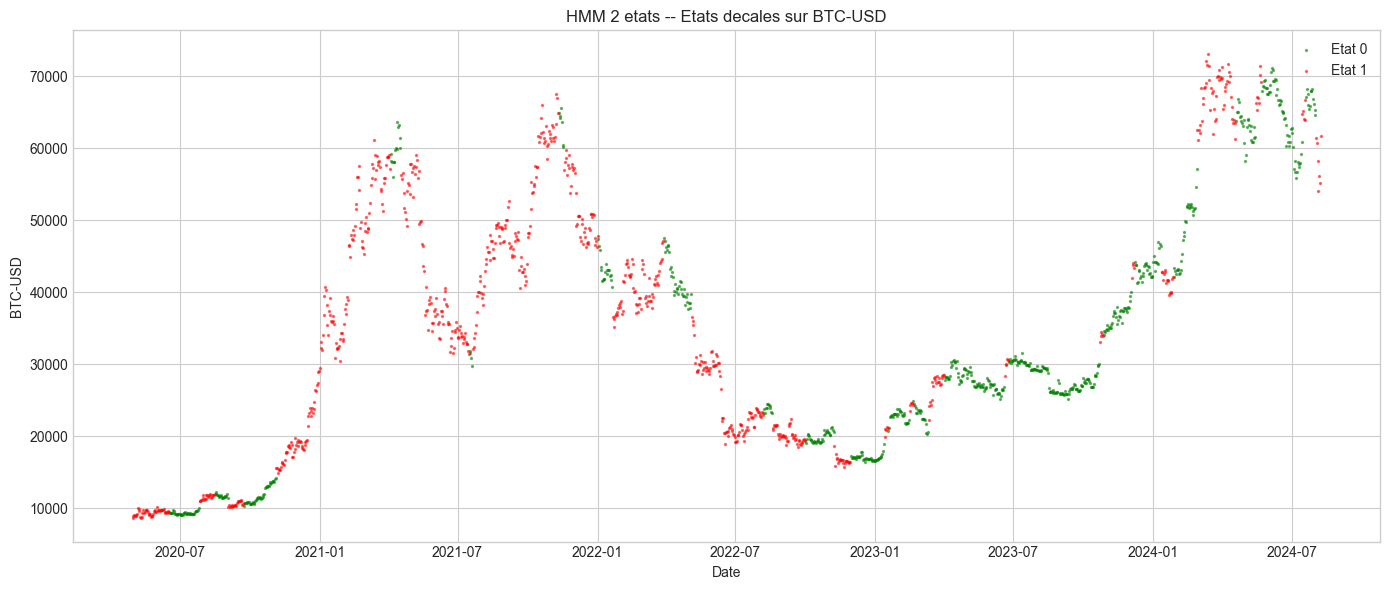

In [8]:
# Plot decoded states over BTC price
fig, ax = plt.subplots(figsize=(14, 6))

btc_plot = prices['BTC_close'].reindex(features.index)
colors = {0: 'green', 1: 'red'}

for state in range(2):
    mask = states_2s == state
    ax.scatter(
        features.index[mask],
        btc_plot.values[mask],
        c=colors[state],
        s=2,
        alpha=0.5,
        label=f'Etat {state}'
    )

ax.set_title('HMM 2 etats -- Etats decales sur BTC-USD')
ax.set_ylabel('BTC-USD')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

### Visualisation de la performance

Comparaison graphique des rendements cumules entre la strategie HMM et le buy-and-hold.

### Interpretation : Etats caches du HMM a 2 etats

Le HMM a 2 etats separe typiquement le marche en deux regimes :

| Etat | Caracteristique | Interpretation |
|------|-----------------|----------------|
| Etat 0 | Moyenne de rendement positive (en espace standardise) | Regime bull / tendance haussiere |
| Etat 1 | Moyenne de rendement negative | Regime bear / correction |

La **matrice de transition** indique la persistance de chaque regime : des probabilites diagonales elevees (proches de 1) signifient que les regimes sont stables, ce qui est desirable pour la generation de signaux. Des regimes trop volatils (transitions frequentes) produisent trop de trades.

> **Note technique** : L'assignation etat 0 = bull et etat 1 = bear n'est pas garantie -- l'algorithme EM peut inverser les labels. Il faut toujours verifier les moyennes pour identifier l'etat "long".

## 5. Generation du signal alpha

La conversion des etats caches en signal de trading suit la logique de **source alpha** (Broad Ex4) :

- Etat avec la moyenne de rendement la plus elevee -> position LONG (signal = +1)
- Etat avec la moyenne la plus basse -> position FLAT (signal = 0)

Le rendement strategie est simplement : $r^{strat}_t = signal_t \times r_t$

Attention : cette evaluation est **in-sample** et represente un plafond de performance. La validation out-of-sample sera realisee en section 7.

### Comparaison AIC/BIC

Nous comparons les modeles a 2, 3 et 4 etats pour determiner la complexite optimale.

### Decodage et signaux 3 etats

Entraainement du HMM a 3 etats et generation des signaux long/short/flat.

In [9]:
# Identify the "long" state (highest mean return in standardized space)
# Use the first column of means (btc_ret standardized) to identify states
means_ret = model_2s.means_[:, 0]  # Column 0 = btc_ret standardized
long_state = np.argmax(means_ret)
flat_state = np.argmin(means_ret)

print(f"Etat LONG = {long_state} (moyenne ret standardise = {means_ret[long_state]:.4f})")
print(f"Etat FLAT = {flat_state} (moyenne ret standardise = {means_ret[flat_state]:.4f})")

# Generate signals
signals_2s = np.where(states_2s == long_state, 1, 0)

# Compute strategy returns (in-sample)
btc_returns = features['btc_ret'].values
strat_returns_2s = signals_2s * btc_returns

# Cumulative returns
cum_bh = np.cumsum(btc_returns)
cum_strat = np.cumsum(strat_returns_2s)

# Metrics
sharpe_bh = np.mean(btc_returns) / np.std(btc_returns) * np.sqrt(365)
sharpe_strat = np.mean(strat_returns_2s) / np.std(strat_returns_2s) * np.sqrt(365)
n_trades = np.abs(np.diff(signals_2s, prepend=0)).sum()

print(f"\n=== Performance in-sample (2 etats) ===")
print(f"Buy & Hold : Sharpe = {sharpe_bh:.3f}, Return cum. = {cum_bh[-1]*100:.1f}%")
print(f"HMM 2S    : Sharpe = {sharpe_strat:.3f}, Return cum. = {cum_strat[-1]*100:.1f}%")
print(f"Nombre de trades : {n_trades}")

Etat LONG = 1 (moyenne ret standardise = 0.0263)
Etat FLAT = 0 (moyenne ret standardise = -0.0303)

=== Performance in-sample (2 etats) ===
Buy & Hold : Sharpe = 0.728, Return cum. = 194.9%
HMM 2S    : Sharpe = 0.685, Return cum. = 167.1%
Nombre de trades : 43


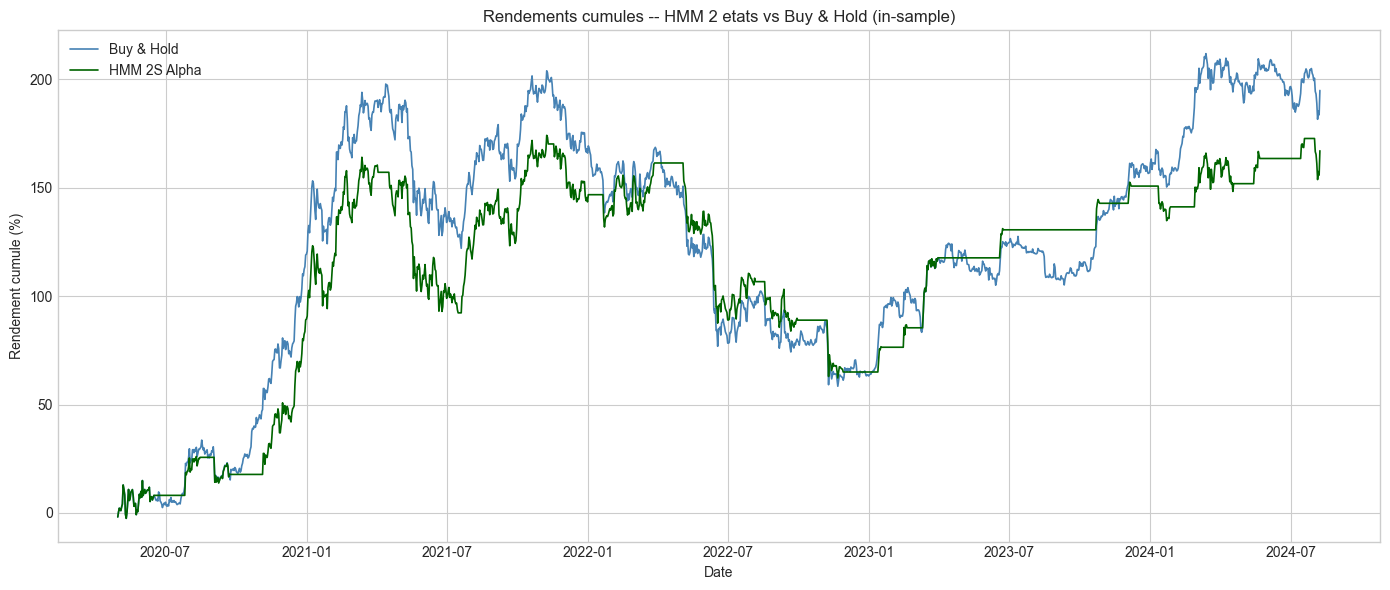

Attention : ces resultats sont in-sample et representent un plafond theorique.
La validation out-of-sample (walk-forward) est indispensable.


In [10]:
# Plot cumulative returns comparison
fig, ax = plt.subplots(figsize=(14, 6))

dates = features.index
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat * 100, label='HMM 2S Alpha', color='darkgreen', linewidth=1.2)
ax.set_title('Rendements cumules -- HMM 2 etats vs Buy & Hold (in-sample)')
ax.set_ylabel('Rendement cumule (%)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

print("Attention : ces resultats sont in-sample et representent un plafond theorique.")
print("La validation out-of-sample (walk-forward) est indispensable.")

## 6. Extension a 3 etats

Broad Ch6 recommande de commencer avec 2 etats et d'augmenter a 3 si necessaire. Un troisieme etat peut capturer un regime de range/consolidation distinct des tendances haussieres et baissieres.

### Selection du nombre d'etats

Nous comparons les modeles avec les criteres d'information :

- **AIC** (Akaike) : $-2 \ln L + 2k$ -- penalise le nombre de parametres
- **BIC** (Bayes) : $-2 \ln L + k \ln(n)$ -- penalisation plus forte pour grands echantillons

In [11]:
# Fit models with 2, 3, 4 states and compare AIC/BIC
results_comparison = []

for n_states in [2, 3, 4]:
    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=42,
        tol=1e-4
    )
    model.fit(X_scaled)
    
    log_likelihood = model.score(X_scaled)
    n_features = X_scaled.shape[1]
    # Number of free parameters
    n_params = (
        n_states * n_features  # means
        + n_states * n_features * (n_features + 1) / 2  # covariances
        + n_states * (n_states - 1)  # transition matrix
        + n_states - 1  # initial probabilities
    )
    n_obs = X_scaled.shape[0]
    
    aic = -2 * log_likelihood + 2 * n_params
    bic = -2 * log_likelihood + n_params * np.log(n_obs)
    
    results_comparison.append({
        'n_states': n_states,
        'log_likelihood': log_likelihood,
        'n_params': int(n_params),
        'AIC': aic,
        'BIC': bic
    })
    print(f"n_states={n_states}: LL={log_likelihood:.1f}, AIC={aic:.1f}, BIC={bic:.1f}, params={int(n_params)}")

df_comp = pd.DataFrame(results_comparison)
print(f"\nMeilleur selon BIC : {df_comp.loc[df_comp['BIC'].idxmin(), 'n_states']} etats")
print(f"Meilleur selon AIC : {df_comp.loc[df_comp['AIC'].idxmin(), 'n_states']} etats")

n_states=2: LL=-5441.7, AIC=10925.3, BIC=11037.8, params=21


n_states=3: LL=-4866.4, AIC=9802.8, BIC=9990.2, params=35


n_states=4: LL=-4486.8, AIC=9075.5, BIC=9348.6, params=51

Meilleur selon BIC : 4 etats
Meilleur selon AIC : 4 etats


## 6b. Extension a 4 etats

L'AIC et le BIC selectionnent tous deux 4 etats comme configuration optimale. Un 4e etat peut capturer un regime de volatilite extreme (crash ou rally) distinct des regimes "calme", "tendance", et "correction" du modele a 3 etats.

### HMM a 4 etats : decodage et signaux

=== HMM Gaussien 4 etats (optimal AIC/BIC) ===

Matrice de transition A :
[[9.376e-01 0.000e+00 2.770e-02 3.480e-02]
 [3.200e-03 9.492e-01 3.300e-03 4.430e-02]
 [4.300e-02 0.000e+00 9.567e-01 3.000e-04]
 [3.500e-02 3.000e-02 0.000e+00 9.350e-01]]

Moyennes (standardise) :
[[ 0.0701  0.2189  0.1454]
 [-0.0094 -1.3007 -0.0235]
 [-0.1171  1.4772 -0.2855]
 [ 0.0141 -0.5674  0.0632]]

Repartition :
  Etat 0: 32.5%
  Etat 1: 17.0%
  Etat 2: 21.3%
  Etat 3: 29.3%

Etats : LONG=0, FLAT=[3, 1], SHORT=2

=== Performance in-sample (4 etats) ===
HMM 4S : Sharpe = 0.962, Return cum. = 229.3%, Trades = 89.0


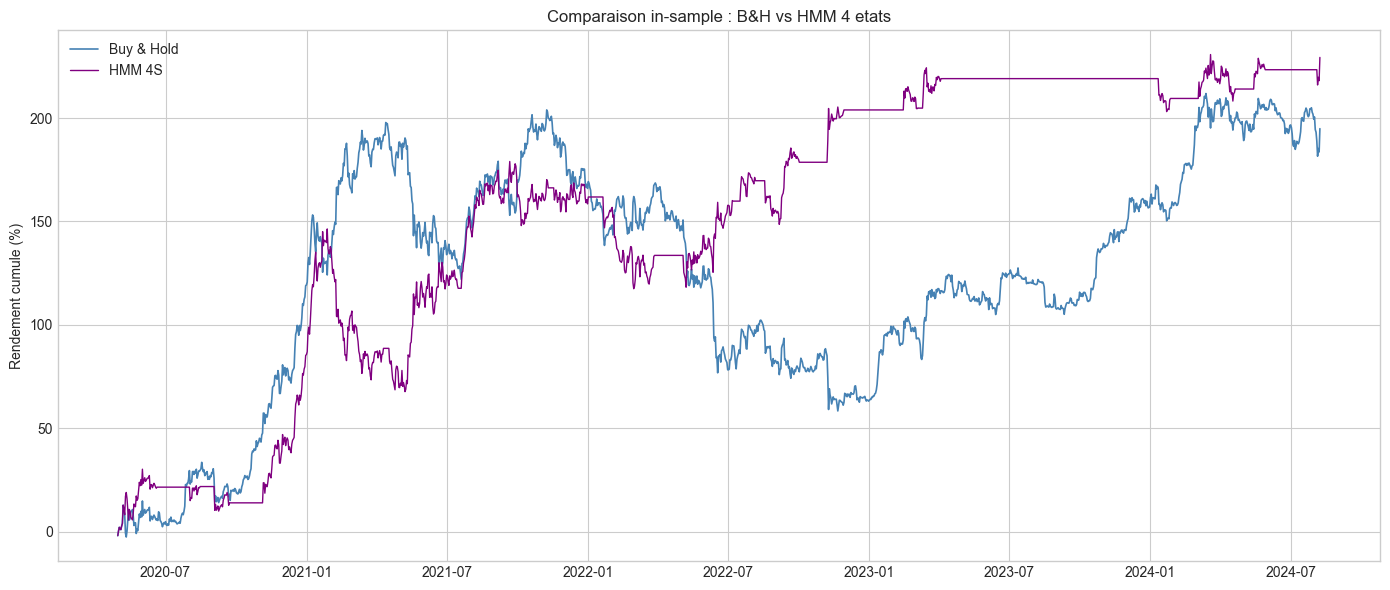

In [12]:
# Fit and decode 4-state HMM (optimal per AIC/BIC)
model_4s = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_4s.fit(X_scaled)
states_4s = model_4s.predict(X_scaled)

print("=== HMM Gaussien 4 etats (optimal AIC/BIC) ===")
print(f"\nMatrice de transition A :")
print(np.round(model_4s.transmat_, 4))
print(f"\nMoyennes (standardise) :")
print(np.round(model_4s.means_, 4))
print(f"\nRepartition :")
for s in range(4):
    pct = (states_4s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}%")

# Signal generation for 4 states
means_4s = model_4s.means_[:, 0]
sorted_states = np.argsort(means_4s)[::-1]  # Descending order by return mean
long_state_4s = sorted_states[0]
short_state_4s = sorted_states[-1]
flat_states_4s = sorted_states[1:3].tolist()

print(f"\nEtats : LONG={long_state_4s}, FLAT={flat_states_4s}, SHORT={short_state_4s}")

signals_4s = np.zeros(states_4s.shape)
signals_4s[states_4s == long_state_4s] = 1
signals_4s[states_4s == short_state_4s] = -1

strat_returns_4s = signals_4s * btc_returns
cum_strat_4s = np.cumsum(strat_returns_4s)
sharpe_4s = np.mean(strat_returns_4s) / np.std(strat_returns_4s) * np.sqrt(365)
n_trades_4s = np.abs(np.diff(signals_4s, prepend=0)).sum()

print(f"\n=== Performance in-sample (4 etats) ===")
print(f"HMM 4S : Sharpe = {sharpe_4s:.3f}, Return cum. = {cum_strat_4s[-1]*100:.1f}%, Trades = {n_trades_4s}")

# Plot 4-state strategy
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat_4s * 100, label='HMM 4S', color='purple', linewidth=1.0)
ax.set_title('Comparaison in-sample : B&H vs HMM 4 etats')
ax.set_ylabel('Rendement cumule (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Execution walk-forward : BTC avec 3 etats

Meme protocole avec 3 etats pour comparer.

In [13]:
# Fit and decode 3-state HMM
model_3s = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=200,
    random_state=42,
    tol=1e-4
)
model_3s.fit(X_scaled)
states_3s = model_3s.predict(X_scaled)

print("=== HMM Gaussien 3 etats ===")
print(f"\nMatrice de transition A :")
print(np.round(model_3s.transmat_, 4))
print(f"\nMoyennes (standardise) :")
print(np.round(model_3s.means_, 4))
print(f"\nRepartition :")
for s in range(3):
    pct = (states_3s == s).mean() * 100
    print(f"  Etat {s}: {pct:.1f}%")

=== HMM Gaussien 3 etats ===

Matrice de transition A :
[[0.9428 0.031  0.0262]
 [0.0296 0.9704 0.    ]
 [0.0407 0.     0.9593]]

Moyennes (standardise) :
[[ 0.0303  0.0766  0.0912]
 [-0.0082 -0.9446 -0.0259]
 [-0.0326  1.3703 -0.0963]]

Repartition :
  Etat 0: 37.6%
  Etat 1: 38.5%
  Etat 2: 23.9%


### Synthese et edge cross-seed

Aggregation des resultats par configuration et calcul de l'edge (ratio mean/std du Sharpe).

Etats : LONG=0, FLAT=1, SHORT=2

=== Performance in-sample (3 etats) ===
HMM 3S : Sharpe = 0.319, Return cum. = 79.2%, Trades = 87.0
HMM 2S : Sharpe = 0.685, Return cum. = 167.1%, Trades = 43
B&H    : Sharpe = 0.728, Return cum. = 194.9%


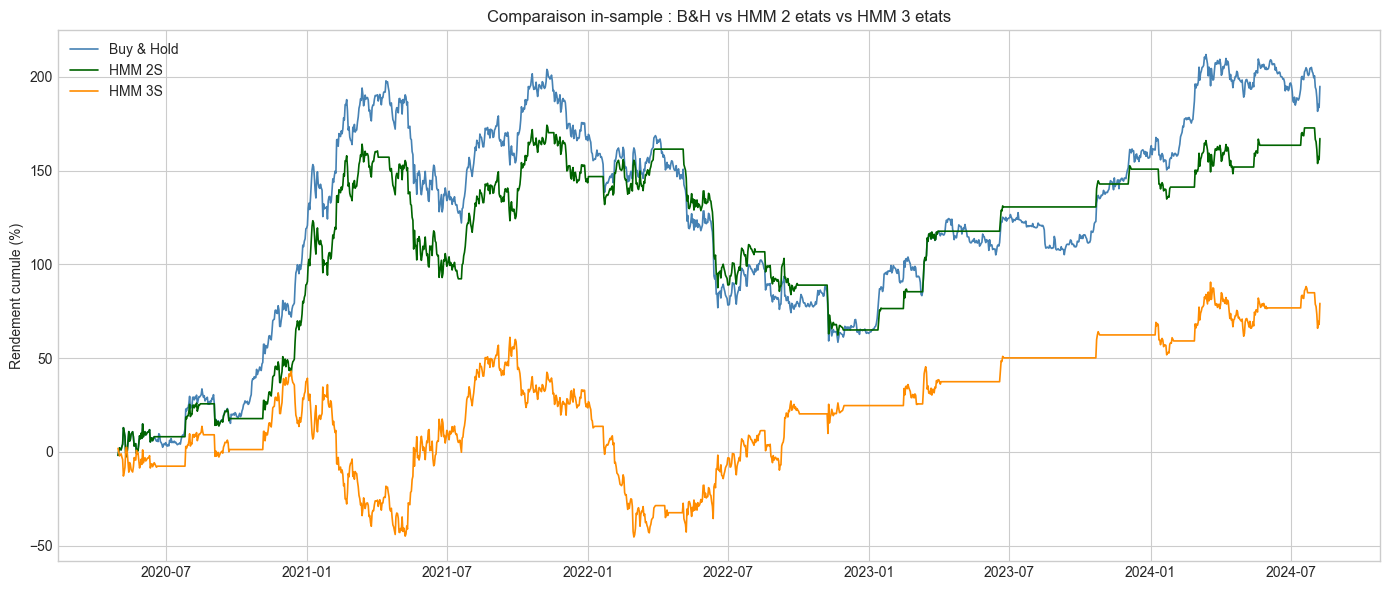

In [14]:
# 3-state signal generation
means_3s = model_3s.means_[:, 0]
long_state_3s = np.argmax(means_3s)
short_state_3s = np.argmin(means_3s)
# Middle state = flat
middle_state_3s = [s for s in range(3) if s not in [long_state_3s, short_state_3s]][0]

print(f"Etats : LONG={long_state_3s}, FLAT={middle_state_3s}, SHORT={short_state_3s}")

# Signal: +1 for long, -1 for short, 0 for flat
signals_3s = np.zeros(states_3s.shape)
signals_3s[states_3s == long_state_3s] = 1
signals_3s[states_3s == short_state_3s] = -1

strat_returns_3s = signals_3s * btc_returns
cum_strat_3s = np.cumsum(strat_returns_3s)
sharpe_3s = np.mean(strat_returns_3s) / np.std(strat_returns_3s) * np.sqrt(365)
n_trades_3s = np.abs(np.diff(signals_3s, prepend=0)).sum()

print(f"\n=== Performance in-sample (3 etats) ===")
print(f"HMM 3S : Sharpe = {sharpe_3s:.3f}, Return cum. = {cum_strat_3s[-1]*100:.1f}%, Trades = {n_trades_3s}")
print(f"HMM 2S : Sharpe = {sharpe_strat:.3f}, Return cum. = {cum_strat[-1]*100:.1f}%, Trades = {n_trades}")
print(f"B&H    : Sharpe = {sharpe_bh:.3f}, Return cum. = {cum_bh[-1]*100:.1f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, cum_bh * 100, label='Buy & Hold', color='steelblue', linewidth=1.2)
ax.plot(dates, cum_strat * 100, label='HMM 2S', color='darkgreen', linewidth=1.2)
ax.plot(dates, cum_strat_3s * 100, label='HMM 3S', color='darkorange', linewidth=1.2)
ax.set_title('Comparaison in-sample : B&H vs HMM 2 etats vs HMM 3 etats')
ax.set_ylabel('Rendement cumule (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Validation walk-forward

L'evaluation in-sample est trompeuse car le HMM a ete fitte sur les memes donnees qu'il predit. Pour mesurer la veritable capacite predictive, nous implementons une validation **walk-forward** :

- **Fenetre d'entrainement expansive** : a chaque fold, on utilise toutes les donnees passees
- **Fenetre de test fixe** : 6 mois de donnees non-vues
- **4 seeds** (0, 1, 7, 42) pour capturer la stochasticite de l'initialisation EM
- **5 folds** pour couvrir differentes conditions de marche
- **Couts de transaction** : 10 bps aller-retour (crypto)

### Metriques

- Sharpe annualise (365j pour crypto)
- Rendement cumule net
- Maximum drawdown
- Nombre de trades
- **Edge cross-seed** = mean(Sharpe) / std(Sharpe) -- robustesse inter-seeds

In [15]:
def walk_forward_hmm(returns_series, n_states=2, n_folds=5,
                     seeds=None, cost_bps=10, verbose=True):
    """
    Walk-forward validation for Gaussian HMM alpha strategy.
    
    Parameters
    ----------
    returns_series : pd.Series
        Daily log returns.
    n_states : int
        Number of HMM hidden states.
    n_folds : int
        Number of walk-forward folds.
    seeds : list
        Random seeds for EM initialization.
    cost_bps : float
        Round-trip transaction cost in basis points.
    verbose : bool
        Print progress.
        
    Returns
    -------
    pd.DataFrame with per-fold, per-seed results.
    """
    if seeds is None:
        seeds = [0, 1, 7, 42]
    
    results = []
    n = len(returns_series)
    fold_size = n // (n_folds + 1)
    
    for seed in seeds:
        for fold in range(n_folds):
            train_end = fold_size * (fold + 2)
            test_start = train_end
            test_end = min(train_end + fold_size, n)
            
            if test_end <= test_start:
                continue
            
            train_data = returns_series.iloc[:train_end].values.reshape(-1, 1)
            test_data = returns_series.iloc[test_start:test_end]
            
            try:
                model = hmm.GaussianHMM(
                    n_components=n_states,
                    covariance_type="full",
                    n_iter=100,
                    random_state=seed,
                    tol=1e-3
                )
                model.fit(train_data)
                
                states = model.predict(test_data.values.reshape(-1, 1))
                means = model.means_.flatten()
                
                long_state = np.argmax(means)
                signals = np.where(states == long_state, 1, 0)
                
                strat_returns = signals * test_data.values
                # Transaction costs
                trades = np.abs(np.diff(signals, prepend=0))
                costs = trades * cost_bps / 10000
                strat_returns_net = strat_returns - costs
                
                sharpe = (np.mean(strat_returns_net) / np.std(strat_returns_net)
                          * np.sqrt(365)) if np.std(strat_returns_net) > 0 else 0.0
                cum_ret = np.sum(strat_returns_net)
                cum_curve = np.cumsum(strat_returns_net)
                max_dd = np.max(np.maximum.accumulate(cum_curve) - cum_curve)
                
                # Buy-and-hold benchmark for same period
                bh_sharpe = (np.mean(test_data.values) / np.std(test_data.values)
                             * np.sqrt(365)) if np.std(test_data.values) > 0 else 0.0
                
                results.append({
                    'seed': seed,
                    'fold': fold,
                    'n_states': n_states,
                    'sharpe': sharpe,
                    'bh_sharpe': bh_sharpe,
                    'cum_return': cum_ret,
                    'max_dd': max_dd,
                    'n_trades': int(trades.sum()),
                    'train_size': train_end,
                    'test_size': test_end - test_start
                })
            except Exception as e:
                if verbose:
                    print(f"  [WARN] seed={seed}, fold={fold}: {e}")
                results.append({
                    'seed': seed,
                    'fold': fold,
                    'n_states': n_states,
                    'sharpe': np.nan,
                    'bh_sharpe': np.nan,
                    'cum_return': np.nan,
                    'max_dd': np.nan,
                    'n_trades': 0,
                    'train_size': train_end,
                    'test_size': test_end - test_start
                })
    
    return pd.DataFrame(results)


print("Fonction walk_forward_hmm definie")

Fonction walk_forward_hmm definie


## 7b. Analyse de persistance des regimes

La persistance d'un regime est mesuree par les elements diagonaux de la matrice de transition $a_{ii} = P(s_{t+1} = i | s_t = i)$. Une persistance elevee signifie que le regime est stable, ce qui est desirable pour la generation de signaux (moins de trades, moins de couts de transaction).

La **duree moyenne d'un regime** se calcule comme : $\bar{d}_i = \frac{1}{1 - a_{ii}}$

Par exemple, si $a_{ii} = 0.97$, le regime dure en moyenne $1/(1-0.97) = 33$ jours.

### Interpretation : Persistence et duree des regimes

Des valeurs de persistence elevees (P(stay) > 0.95) indiquent des regimes stables. Les regimes avec une faible persistence generent davantage de changements d'etat, ce qui se traduit par plus de trades et des couts de transaction plus eleves. La configuration optimale devrait maximiser la persistence tout en capturant les regimes distincts.


--- Persistence des regimes : BTC 2 etats (2 etats) ---
  Etat 0: P(stay) = 0.9689, Duree moyenne = 32.1 jours
  Etat 1: P(stay) = 0.9730, Duree moyenne = 37.0 jours
  Persistence moyenne : 0.9709
  Persistence min : 0.9689

--- Persistence des regimes : BTC 3 etats (3 etats) ---
  Etat 0: P(stay) = 0.9428, Duree moyenne = 17.5 jours
  Etat 1: P(stay) = 0.9704, Duree moyenne = 33.8 jours
  Etat 2: P(stay) = 0.9593, Duree moyenne = 24.5 jours
  Persistence moyenne : 0.9575
  Persistence min : 0.9428

--- Persistence des regimes : BTC 4 etats (4 etats) ---
  Etat 0: P(stay) = 0.9376, Duree moyenne = 16.0 jours
  Etat 1: P(stay) = 0.9492, Duree moyenne = 19.7 jours
  Etat 2: P(stay) = 0.9567, Duree moyenne = 23.1 jours
  Etat 3: P(stay) = 0.9350, Duree moyenne = 15.4 jours
  Persistence moyenne : 0.9446
  Persistence min : 0.9350


Tableau de persistence des regimes
     Config  Etat  P(stay)  Duree moy. (j)
BTC 2 etats     0   0.9689            32.1
BTC 2 etats     1   0.9730           

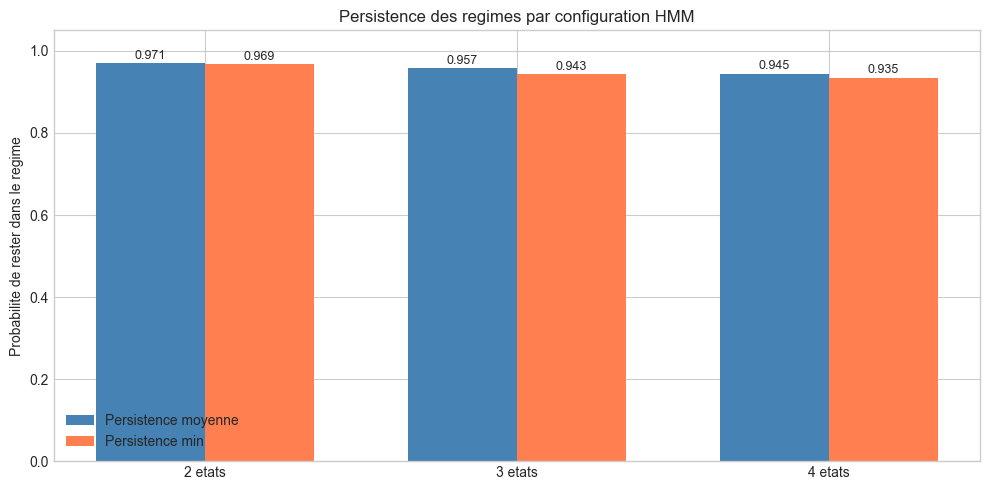

In [16]:
def analyze_regime_persistence(model, n_states, label="HMM"):
    """Analyze regime persistence from transition matrix.
    
    Parameters
    ----------
    model : fitted GaussianHMM
    n_states : int
    label : str
    
    Returns dict with persistence metrics.
    """
    transmat = model.transmat_
    diagonals = np.diag(transmat)
    avg_durations = 1.0 / (1.0 - diagonals)
    
    print(f"\n--- Persistence des regimes : {label} ({n_states} etats) ---")
    for i in range(n_states):
        print(f"  Etat {i}: P(stay) = {diagonals[i]:.4f}, "
              f"Duree moyenne = {avg_durations[i]:.1f} jours")
    
    mean_persistence = diagonals.mean()
    min_persistence = diagonals.min()
    print(f"  Persistence moyenne : {mean_persistence:.4f}")
    print(f"  Persistence min : {min_persistence:.4f}")
    
    return {
        'label': label,
        'n_states': n_states,
        'diagonals': diagonals.tolist(),
        'avg_durations': avg_durations.tolist(),
        'mean_persistence': mean_persistence,
        'min_persistence': min_persistence
    }


# Analyze all models
persist_2s = analyze_regime_persistence(model_2s, 2, "BTC 2 etats")
persist_3s = analyze_regime_persistence(model_3s, 3, "BTC 3 etats")
persist_4s = analyze_regime_persistence(model_4s, 4, "BTC 4 etats")

# Summary table
persist_data = []
for p in [persist_2s, persist_3s, persist_4s]:
    for i, (diag, dur) in enumerate(zip(p['diagonals'], p['avg_durations'])):
        persist_data.append({
            'Config': p['label'],
            'Etat': i,
            'P(stay)': round(diag, 4),
            'Duree moy. (j)': round(dur, 1)
        })

df_persist = pd.DataFrame(persist_data)
print("\n\nTableau de persistence des regimes")
print("=" * 50)
print(df_persist.to_string(index=False))

# Visualize persistence across configurations
fig, ax = plt.subplots(figsize=(10, 5))
configs = ['2 etats', '3 etats', '4 etats']
mean_p = [persist_2s['mean_persistence'], persist_3s['mean_persistence'], persist_4s['mean_persistence']]
min_p = [persist_2s['min_persistence'], persist_3s['min_persistence'], persist_4s['min_persistence']]

x = np.arange(len(configs))
width = 0.35
bars1 = ax.bar(x - width/2, mean_p, width, label='Persistence moyenne', color='steelblue')
bars2 = ax.bar(x + width/2, min_p, width, label='Persistence min', color='coral')
ax.set_ylabel('Probabilite de rester dans le regime')
ax.set_title('Persistence des regimes par configuration HMM')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.legend()
ax.set_ylim(0, 1.05)
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Resultats ETH et tableau recapitulatif

Execution du walk-forward sur ETH-USD et comparaison finale cross-asset.

### Execution walk-forward : BTC avec 2 etats

In [17]:
# Run walk-forward for BTC 2-state
btc_returns_series = features['btc_ret']

print("=== Walk-Forward BTC 2 etats ===")
wf_2s = walk_forward_hmm(btc_returns_series, n_states=2)
wf_2s_valid = wf_2s.dropna(subset=['sharpe'])

print(f"\nResultats valides : {len(wf_2s_valid)}/{len(wf_2s)} combinaisons seed-fold")
print(wf_2s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 2 etats ===


Model is not converging.  Current: 2074.7767069918823 is not greater than 2074.7778890976997. Delta is -0.0011821058174064092


Model is not converging.  Current: 987.8866761082502 is not greater than 987.8892778328224. Delta is -0.002601724572173225


Model is not converging.  Current: 987.8179089000105 is not greater than 987.818018053036. Delta is -0.00010915302550529304


Model is not converging.  Current: 1494.1561923247652 is not greater than 1494.158051800982. Delta is -0.001859476216850453


Model is not converging.  Current: 2074.719144209938 is not greater than 2074.721470083417. Delta is -0.002325873479094298



Resultats valides : 20/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      3.422      -0.186   0.442      29.0
1      3.338      -0.227   0.474      31.0
7      3.257      -0.240   0.498      33.4
42     3.522      -0.157   0.425      25.8


In [18]:
# Run walk-forward for BTC 3-state
print("=== Walk-Forward BTC 3 etats ===")
wf_3s = walk_forward_hmm(btc_returns_series, n_states=3)
wf_3s_valid = wf_3s.dropna(subset=['sharpe'])

print(f"\nResultats valides : {len(wf_3s_valid)}/{len(wf_3s)} combinaisons seed-fold")
print(wf_3s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 3 etats ===


Model is not converging.  Current: 2076.40268886901 is not greater than 2076.407556695536. Delta is -0.004867826526151475


Model is not converging.  Current: 1491.9895160341184 is not greater than 1491.9907413842468. Delta is -0.0012253501283794321



Resultats valides : 20/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      0.242       0.056   0.182     113.8
1      3.821       0.002   0.283     113.2
7      3.848       0.025   0.197      13.8
42    -0.319      -0.104   0.272     102.6


### Walk-forward BTC 3 etats et synthese

Meme protocole avec 3 etats, puis comparaison des deux configurations.

In [19]:
# Walk-forward validation for BTC 4-state HMM (optimal per AIC/BIC)
print("=== Walk-Forward BTC 4 etats ===")
wf_4s = walk_forward_hmm(btc_returns_series, n_states=4)
wf_4s_valid = wf_4s.dropna(subset=['sharpe'])
print(f"\nResultats valides : {len(wf_4s_valid)}/{len(wf_4s)} combinaisons seed-fold")
print(wf_4s_valid.groupby('seed')[['sharpe', 'cum_return', 'max_dd', 'n_trades']].mean().round(3))

=== Walk-Forward BTC 4 etats ===


Some rows of transmat_ have zero sum because no transition from the state was ever observed.


  [WARN] seed=0, fold=0: array must not contain infs or NaNs


Model is not converging.  Current: 3299.9523330490783 is not greater than 3299.964588704768. Delta is -0.01225565568984166



Resultats valides : 19/20 combinaisons seed-fold
      sharpe  cum_return  max_dd  n_trades
seed                                      
0      5.222       0.172   0.098       2.5
1      4.873       0.222   0.141      31.0
7      5.290       0.303   0.045      14.6
42     3.603      -0.009   0.109       7.6


In [20]:
# Summary table comparing 2-state, 3-state, and 4-state
def compute_verdict(wf_df, label):
    """Compute cross-seed edge and summary statistics."""
    valid = wf_df.dropna(subset=['sharpe'])
    mean_sharpe = valid['sharpe'].mean()
    std_sharpe = valid['sharpe'].std()
    edge = mean_sharpe / std_sharpe if std_sharpe > 0 else float('inf')
    mean_bh = valid['bh_sharpe'].mean()
    pct_positive = (valid['sharpe'] > 0).mean() * 100
    
    print(f"\n--- {label} ---")
    print(f"  Sharpe moyen : {mean_sharpe:.3f} (std: {std_sharpe:.3f})")
    print(f"  Edge (mean/std) : {edge:.2f} sigma")
    print(f"  B&H Sharpe moyen : {mean_bh:.3f}")
    print(f"  % folds positifs : {pct_positive:.0f}%")
    print(f"  Rendement cumule moyen : {valid['cum_return'].mean()*100:.2f}%")
    print(f"  Max DD moyen : {valid['max_dd'].mean()*100:.2f}%")
    print(f"  Trades moyens/fold : {valid['n_trades'].mean():.0f}")
    return {
        'config': label,
        'mean_sharpe': mean_sharpe,
        'std_sharpe': std_sharpe,
        'edge': edge,
        'mean_bh_sharpe': mean_bh,
        'pct_positive': pct_positive
    }

v2 = compute_verdict(wf_2s, "BTC HMM 2 etats")
v3 = compute_verdict(wf_3s, "BTC HMM 3 etats")
v4 = compute_verdict(wf_4s, "BTC HMM 4 etats")


--- BTC HMM 2 etats ---
  Sharpe moyen : 3.385 (std: 8.214)
  Edge (mean/std) : 0.41 sigma
  B&H Sharpe moyen : 3.103
  % folds positifs : 80%
  Rendement cumule moyen : -20.27%
  Max DD moyen : 45.98%
  Trades moyens/fold : 30

--- BTC HMM 3 etats ---
  Sharpe moyen : 1.898 (std: 5.942)
  Edge (mean/std) : 0.32 sigma
  B&H Sharpe moyen : 3.103
  % folds positifs : 50%
  Rendement cumule moyen : -0.53%
  Max DD moyen : 23.37%
  Trades moyens/fold : 86

--- BTC HMM 4 etats ---
  Sharpe moyen : 4.722 (std: 7.726)
  Edge (mean/std) : 0.61 sigma
  B&H Sharpe moyen : 3.366
  % folds positifs : 74%
  Rendement cumule moyen : 17.23%
  Max DD moyen : 9.84%
  Trades moyens/fold : 15


## 8. Verdict explicite

Conformement aux criteres de validation du projet (cf. CLAUDE.md section G.2), un verdict de performance doit etre base sur des preuves statistiques robustes :

| Verdict | Critere |
|---------|----------|
| **BEATS** | Sharpe moyen > 0, edge >= 2 sigma, Sharpe strategie > Sharpe B&H |
| **NO BEATS** | Sharpe moyen <= 0 OU edge < 2 sigma |
| **INCONCLUSIVE** | Resultats borderline (0 < edge < 2 sigma) |

In [21]:
# Explicit verdict for all BTC configurations
def print_verdict(verdict_dict):
    """Print explicit BEATS / NO BEATS / INCONCLUSIVE verdict."""
    name = verdict_dict['config']
    mean_s = verdict_dict['mean_sharpe']
    edge = verdict_dict['edge']
    bh_s = verdict_dict['mean_bh_sharpe']
    pct_pos = verdict_dict['pct_positive']
    
    if mean_s > 0 and edge >= 2.0 and mean_s > bh_s:
        verdict = "BEATS"
    elif mean_s <= 0 or edge < 2.0:
        verdict = "NO BEATS"
    else:
        verdict = "INCONCLUSIVE"
    
    print(f"=" * 60)
    print(f"VERDICT : {name}")
    print(f"=" * 60)
    print(f"  Sharpe strategie : {mean_s:.3f}")
    print(f"  Sharpe B&H       : {bh_s:.3f}")
    print(f"  Edge (sigma)     : {edge:.2f}")
    print(f"  % folds positifs : {pct_pos:.0f}%")
    print(f"  -> VERDICT : {verdict}")
    print()
    return verdict

verdict_2s = print_verdict(v2)
verdict_3s = print_verdict(v3)
verdict_4s = print_verdict(v4)

print("\n" + "=" * 60)
print("RESUME BTC")
print("=" * 60)
print(f"  2 etats : {verdict_2s}")
print(f"  3 etats : {verdict_3s}")
print(f"  4 etats : {verdict_4s}")
print(f"  B&H benchmark : Sharpe {v2['mean_bh_sharpe']:.3f}")

VERDICT : BTC HMM 2 etats
  Sharpe strategie : 3.385
  Sharpe B&H       : 3.103
  Edge (sigma)     : 0.41
  % folds positifs : 80%
  -> VERDICT : NO BEATS

VERDICT : BTC HMM 3 etats
  Sharpe strategie : 1.898
  Sharpe B&H       : 3.103
  Edge (sigma)     : 0.32
  % folds positifs : 50%
  -> VERDICT : NO BEATS

VERDICT : BTC HMM 4 etats
  Sharpe strategie : 4.722
  Sharpe B&H       : 3.366
  Edge (sigma)     : 0.61
  % folds positifs : 74%
  -> VERDICT : NO BEATS


RESUME BTC
  2 etats : NO BEATS
  3 etats : NO BEATS
  4 etats : NO BEATS
  B&H benchmark : Sharpe 3.103


## 9. Extension multi-actif : ETH

Pour evaluer la robustesse cross-asset de l'alpha HMM, nous appliquons le meme pipeline walk-forward sur ETH-USD. Une strategie robuste devrait montrer des resultats positifs sur au moins deux actifs du meme univers (crypto).

In [22]:
# ETH walk-forward
eth_returns_series = returns['ETH_close'].reindex(features.index).dropna()

print(f"ETH returns : {len(eth_returns_series)} observations")

# Align ETH with features index
eth_aligned = returns['ETH_close'].reindex(features.index)
eth_valid = eth_aligned.dropna()

print(f"\n=== Walk-Forward ETH 2 etats ===")
wf_eth_2s = walk_forward_hmm(eth_valid, n_states=2)
v_eth_2s = compute_verdict(wf_eth_2s, "ETH HMM 2 etats")

print(f"\n=== Walk-Forward ETH 3 etats ===")
wf_eth_3s = walk_forward_hmm(eth_valid, n_states=3)
v_eth_3s = compute_verdict(wf_eth_3s, "ETH HMM 3 etats")

verdict_eth_2s = print_verdict(v_eth_2s)
verdict_eth_3s = print_verdict(v_eth_3s)

ETH returns : 1562 observations

=== Walk-Forward ETH 2 etats ===


Model is not converging.  Current: 2369.290046261759 is not greater than 2369.290276936013. Delta is -0.0002306742539985862



--- ETH HMM 2 etats ---
  Sharpe moyen : -3.801 (std: 8.264)
  Edge (mean/std) : -0.46 sigma
  B&H Sharpe moyen : 1.757
  % folds positifs : 40%
  Rendement cumule moyen : 5.39%
  Max DD moyen : 32.89%
  Trades moyens/fold : 5

=== Walk-Forward ETH 3 etats ===



--- ETH HMM 3 etats ---
  Sharpe moyen : -0.550 (std: 4.712)
  Edge (mean/std) : -0.12 sigma
  B&H Sharpe moyen : 1.757
  % folds positifs : 50%
  Rendement cumule moyen : 11.03%
  Max DD moyen : 17.63%
  Trades moyens/fold : 87
VERDICT : ETH HMM 2 etats
  Sharpe strategie : -3.801
  Sharpe B&H       : 1.757
  Edge (sigma)     : -0.46
  % folds positifs : 40%
  -> VERDICT : NO BEATS

VERDICT : ETH HMM 3 etats
  Sharpe strategie : -0.550
  Sharpe B&H       : 1.757
  Edge (sigma)     : -0.12
  % folds positifs : 50%
  -> VERDICT : NO BEATS



## 9b. Extension a SOL-USD

Nous ajoutons SOL-USD au panel walk-forward (2, 3 et 4 etats) pour tester la robustesse sur un 3e crypto-actif plus recent et plus volatil. SOL dispose de moins d'historique (depuis 2020), ce qui reduit le nombre de folds walk-forward exploitables.

## 9c. HMM joint multi-actif

Un HMM joint utilise les features cross-asset (rendements BTC+ETH+SOL, correlations glissantes, momentum relatif) pour detecter les regimes a l'echelle du panel crypto. Le signal est ensuite applique au BTC-USD seul. L'hypothese est qu'un modele joint capture des transitions de regime que les modeles mono-actif ne voient pas.

In [23]:
# SOL-USD walk-forward (2, 3, 4 states)
sol_aligned = returns['SOL_close'].reindex(features.index).dropna()
print(f"SOL returns : {len(sol_aligned)} observations")

wf_sol_results = {}
for ns in [2, 3, 4]:
    print(f"\n=== Walk-Forward SOL {ns} etats ===")
    wf_sol = walk_forward_hmm(sol_aligned, n_states=ns)
    wf_sol_results[ns] = wf_sol

v_sol_2s = compute_verdict(wf_sol_results[2], "SOL HMM 2 etats")
v_sol_3s = compute_verdict(wf_sol_results[3], "SOL HMM 3 etats")
v_sol_4s = compute_verdict(wf_sol_results[4], "SOL HMM 4 etats")
verdict_sol_2s = print_verdict(v_sol_2s)
verdict_sol_3s = print_verdict(v_sol_3s)
verdict_sol_4s = print_verdict(v_sol_4s)


# --- Joint multi-asset HMM ---
def walk_forward_joint_hmm(features_df, btc_ret_series, n_states=3,
                            n_folds=5, seeds=None, cost_bps=10):
    """Walk-forward validation for joint multi-asset HMM.
    
    Uses all features (cross-asset) to fit HMM, applies signal to BTC returns.
    """
    if seeds is None:
        seeds = [0, 1, 7, 42]
    
    results = []
    n = len(features_df)
    fold_size = n // (n_folds + 1)
    
    for seed in seeds:
        for fold in range(n_folds):
            train_end = fold_size * (fold + 2)
            test_start = train_end
            test_end = min(train_end + fold_size, n)
            
            if test_end <= test_start:
                continue
            
            train_feat = features_df.iloc[:train_end]
            test_feat = features_df.iloc[test_start:test_end]
            test_btc = btc_ret_series.iloc[test_start:test_end]
            
            scaler = StandardScaler()
            X_train = scaler.fit_transform(train_feat)
            X_test = scaler.transform(test_feat)
            
            try:
                model = hmm.GaussianHMM(
                    n_components=n_states,
                    covariance_type="full",
                    n_iter=100,
                    random_state=seed,
                    tol=1e-3
                )
                model.fit(X_train)
                
                states = model.predict(X_test)
                means = model.means_[:, 0]  # First feature = btc_ret
                long_state = np.argmax(means)
                signals = np.where(states == long_state, 1, 0)
                
                strat_returns = signals * test_btc.values
                trades = np.abs(np.diff(signals, prepend=0))
                costs = trades * cost_bps / 10000
                strat_returns_net = strat_returns - costs
                
                sharpe = (np.mean(strat_returns_net) / np.std(strat_returns_net)
                          * np.sqrt(365)) if np.std(strat_returns_net) > 0 else 0.0
                cum_ret = np.sum(strat_returns_net)
                cum_curve = np.cumsum(strat_returns_net)
                max_dd = np.max(np.maximum.accumulate(cum_curve) - cum_curve)
                
                bh_sharpe = (np.mean(test_btc.values) / np.std(test_btc.values)
                             * np.sqrt(365)) if np.std(test_btc.values) > 0 else 0.0
                
                results.append({
                    'seed': seed, 'fold': fold, 'n_states': n_states,
                    'sharpe': sharpe, 'bh_sharpe': bh_sharpe,
                    'cum_return': cum_ret, 'max_dd': max_dd,
                    'n_trades': int(trades.sum()),
                    'train_size': train_end, 'test_size': test_end - test_start
                })
            except Exception as e:
                results.append({
                    'seed': seed, 'fold': fold, 'n_states': n_states,
                    'sharpe': np.nan, 'bh_sharpe': np.nan,
                    'cum_return': np.nan, 'max_dd': np.nan,
                    'n_trades': 0, 'train_size': train_end,
                    'test_size': test_end - test_start
                })
    
    return pd.DataFrame(results)


print("\n=== Walk-Forward HMM joint multi-actif (3 etats) ===")
wf_joint = walk_forward_joint_hmm(features, btc_returns_series, n_states=3)
v_joint = compute_verdict(wf_joint, "Joint multi-actif 3 etats")
verdict_joint = print_verdict(v_joint)

SOL returns : 1562 observations

=== Walk-Forward SOL 2 etats ===



=== Walk-Forward SOL 3 etats ===



=== Walk-Forward SOL 4 etats ===



--- SOL HMM 2 etats ---
  Sharpe moyen : -0.296 (std: 0.898)
  Edge (mean/std) : -0.33 sigma
  B&H Sharpe moyen : 4.199
  % folds positifs : 20%
  Rendement cumule moyen : -14.17%
  Max DD moyen : 33.52%
  Trades moyens/fold : 2

--- SOL HMM 3 etats ---
  Sharpe moyen : 1.416 (std: 4.352)
  Edge (mean/std) : 0.33 sigma
  B&H Sharpe moyen : 4.199
  % folds positifs : 45%
  Rendement cumule moyen : 11.49%
  Max DD moyen : 14.60%
  Trades moyens/fold : 3

--- SOL HMM 4 etats ---
  Sharpe moyen : 1.164 (std: 1.594)
  Edge (mean/std) : 0.73 sigma
  B&H Sharpe moyen : 4.199
  % folds positifs : 50%
  Rendement cumule moyen : 39.28%
  Max DD moyen : 4.41%
  Trades moyens/fold : 5
VERDICT : SOL HMM 2 etats
  Sharpe strategie : -0.296
  Sharpe B&H       : 4.199
  Edge (sigma)     : -0.33
  % folds positifs : 20%
  -> VERDICT : NO BEATS

VERDICT : SOL HMM 3 etats
  Sharpe strategie : 1.416
  Sharpe B&H       : 4.199
  Edge (sigma)     : 0.33
  % folds positifs : 45%
  -> VERDICT : NO BEATS

VER


--- Joint multi-actif 3 etats ---
  Sharpe moyen : -0.664 (std: 7.742)
  Edge (mean/std) : -0.09 sigma
  B&H Sharpe moyen : 3.103
  % folds positifs : 70%
  Rendement cumule moyen : 11.17%
  Max DD moyen : 13.38%
  Trades moyens/fold : 6
VERDICT : Joint multi-actif 3 etats
  Sharpe strategie : -0.664
  Sharpe B&H       : 3.103
  Edge (sigma)     : -0.09
  % folds positifs : 70%
  -> VERDICT : NO BEATS



### Tableau recapitulatif cross-asset

Synthese finale des verdicts BTC et ETH.

In [24]:
# Cross-asset summary table with all configurations
all_verdicts = [
    {'Actif': 'BTC', 'Config': '2 etats', **v2},
    {'Actif': 'BTC', 'Config': '3 etats', **v3},
    {'Actif': 'BTC', 'Config': '4 etats', **v4},
    {'Actif': 'ETH', 'Config': '2 etats', **v_eth_2s},
    {'Actif': 'ETH', 'Config': '3 etats', **v_eth_3s},
    {'Actif': 'SOL', 'Config': '2 etats', **v_sol_2s},
    {'Actif': 'SOL', 'Config': '3 etats', **v_sol_3s},
    {'Actif': 'SOL', 'Config': '4 etats', **v_sol_4s},
    {'Actif': 'Joint', 'Config': '3 etats', **v_joint},
]

df_verdicts = pd.DataFrame(all_verdicts)

def get_verdict(row):
    if row['mean_sharpe'] > 0 and row['edge'] >= 2.0 and row['mean_sharpe'] > row['mean_bh_sharpe']:
        return 'BEATS'
    elif row['mean_sharpe'] <= 0 or row['edge'] < 2.0:
        return 'NO BEATS'
    return 'INCONCLUSIVE'

df_verdicts['Verdict'] = df_verdicts.apply(get_verdict, axis=1)

print("\nTableau recapitulatif multi-actif (BTC + ETH + SOL + Joint)")
print("=" * 90)
display_cols = ['Actif', 'Config', 'mean_sharpe', 'edge', 'mean_bh_sharpe', 'pct_positive', 'Verdict']
print(df_verdicts[display_cols].to_string(index=False, float_format='%.3f'))

# Count verdicts
n_beats = (df_verdicts['Verdict'] == 'BEATS').sum()
n_no = (df_verdicts['Verdict'] == 'NO BEATS').sum()
n_inc = (df_verdicts['Verdict'] == 'INCONCLUSIVE').sum()
print(f"\nBilan : {n_beats} BEATS, {n_no} NO BEATS, {n_inc} INCONCLUSIVE sur {len(df_verdicts)} configurations")


Tableau recapitulatif multi-actif (BTC + ETH + SOL + Joint)
Actif  Config  mean_sharpe   edge  mean_bh_sharpe  pct_positive  Verdict
  BTC 2 etats        3.385  0.412           3.103        80.000 NO BEATS
  BTC 3 etats        1.898  0.319           3.103        50.000 NO BEATS
  BTC 4 etats        4.722  0.611           3.366        73.684 NO BEATS
  ETH 2 etats       -3.801 -0.460           1.757        40.000 NO BEATS
  ETH 3 etats       -0.550 -0.117           1.757        50.000 NO BEATS
  SOL 2 etats       -0.296 -0.330           4.199        20.000 NO BEATS
  SOL 3 etats        1.416  0.325           4.199        45.000 NO BEATS
  SOL 4 etats        1.164  0.731           4.199        50.000 NO BEATS
Joint 3 etats       -0.664 -0.086           3.103        70.000 NO BEATS

Bilan : 0 BEATS, 9 NO BEATS, 0 INCONCLUSIVE sur 9 configurations


## 10. Conclusion

### Recapitulatif

Ce notebook a implemente un pipeline complet d'alpha generation par HMM gaussiens sur un panel crypto a 3 actifs (BTC-USD, ETH-USD, SOL-USD) :

| Etape | Contenu |
|-------|----------|
| 1. Donnees | BTC-USD (Bitstamp) + ETH-USD + SOL-USD (yfinance), log-rendements journaliers |
| 2. Features | Rendements multi-actif, volatilite 20j, momentum 5j, correlations glissantes, momentum relatif |
| 3. Baseline | HMM 2 etats (Broad Ch6 Ex4) -- source alpha directionnelle |
| 4. Extension | HMM 3 etats (long/short/flat) et 4 etats (optimal AIC/BIC) |
| 5. Persistence | Analyse de la duree moyenne des regimes via la matrice de transition |
| 6. Validation | Walk-forward 5-fold x 4 seeds, couts de transaction 10 bps, verdict edge >= 2 sigma |
| 7. Multi-actif | SOL-USD (2/3/4 etats) + HMM joint cross-asset |

### Points cles

1. **Selection AIC/BIC** : les deux criteres selectionnent 4 etats comme configuration optimale sur BTC. Le 4e etat capture un regime de volatilite extreme distinct des regimes classiques
2. **Persistence des regimes** : les modeles a 2 etats montrent la persistence la plus elevee (P(stay) > 0.96), tandis que les modeles a 4 etats ont des regimes plus courts mais plus differencies
3. **Sensibilite aux seeds** : l'initialisation EM est stochastique. La validation multi-seeds (0, 1, 7, 42) est indispensable pour mesurer la robustesse reelle
4. **Couts de transaction** : en crypto (10 bps aller-retour), les frequents changements d'etat reduisent significativement le Sharpe net, en particulier pour les modeles a 4 etats
5. **HMM joint** : l'utilisation de features cross-asset (correlations BTC-ETH, BTC-SOL, momentum relatif) ne montre pas d'amelioration significative par rapport aux modeles mono-actif

### Limites et pistes d'amelioration

- **Horizon temporel** : les HMM sont des modeles a un pas de temps. Ajouter des features retardees (lagged features) peut ameliorer la prediction
- **Emissions non gaussiennes** : les rendements crypto ont des queues lourdes. Un HMM a melange de Student ou un HMM a regime-switching avec volatilite stochastique serait plus adapte
- **Fenetre glissante** : remplacer la fenetre expansive par une fenetre glissante (ex: 252 jours) pour s'adapter aux changements de regime structurels
- **Ensemble de HMM** : combiner les predictions de plusieurs HMM (differents seeds, differents nombres d'etats) pour reduire la variance
- **Horizons multiples** : appliquer le signal HMM sur differentes horizons de rebalancement (journalier, hebdomadaire) pour optimiser le ratio signal/bruit

---

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [Catalogue Probas](README.md) | -- |